# Asking the Auditor — Analysis

Reproduces every table and figure reported in *Asking the Auditor: How Members of
Parliament Use Questions about Audits to Control the Executive*.

**Data.** 1,778 written parliamentary questions and 1,703 answers exchanged between
the Dutch House of Representatives and the Netherlands Court of Audit (Algemene
Rekenkamer, 2011–2025), annotated with a large language model (Claude Opus 4.6)
against the taxonomy in `docs/annotation-guidelines.md`. The LLM annotation was
validated against a manually coded reference sample of 250 questions and 251
answers.

**Label mapping.** Source files use the original Dutch schema labels
(`FEIT`/`CAU`/`OOR`/`ADV`/`DEFL`); the paper reports them in English
(`FACT`/`CAU`/`EVAL`/`PRES`/`DEFL`). Both refer to the same ordinal scale:

```
FACT → CAU → EVAL → PRES        (questions: demand)
FACT → CAU → EVAL → PRES → DEFL (answers: response type)
```


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

sys.path.insert(0, str(Path.cwd()))
from metrics import cohen_kappa, weighted_kappa, classification_metrics, confusion_matrix_df

DATA = Path("data")
FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)

sns.set_theme(style="white")
plt.rcParams["font.family"] = ["Helvetica", "Nimbus Sans", "Arial", "Liberation Sans", "DejaVu Sans"]
pd.set_option("display.float_format", "{:.3f}".format)

LABEL_MAP = {"FEIT": "FACT", "CAU": "CAU", "OOR": "EVAL", "ADV": "PRES", "DEFL": "DEFL"}
Q_LABELS = ["FACT", "CAU", "EVAL", "PRES"]
A_LABELS = ["FACT", "CAU", "EVAL", "PRES", "DEFL"]


## 1. Load data

* `questions_llm_annotated.csv` / `answers_llm_annotated.csv` — full corpus, LLM-annotated
* `questions_manual_annotated.csv` / `answers_manual_annotated.csv` — same corpus; the
  `label` column is populated only for the manually coded reference sample (n=250 / n=251)
* `deflection_taxonomy.csv` — the 459 deflected (DEFL) answers, manually sub-coded into
  five deflection types
* `committees.csv` — maps each source document to the submitting parliamentary
  committee, used to infer policy domain


In [2]:
q = pd.read_csv(DATA / "questions_llm_annotated.csv", sep="\t")
a = pd.read_csv(DATA / "answers_llm_annotated.csv", sep="\t")
mq = pd.read_csv(DATA / "questions_manual_annotated.csv", sep="\t")
ma = pd.read_csv(DATA / "answers_manual_annotated.csv", sep="\t")
defl = pd.read_csv(DATA / "deflection_taxonomy.csv", sep="\t")
committees = pd.read_csv(DATA / "committees.csv")

q["label"] = q["llm_label"].map(LABEL_MAP)
a["label"] = a["llm_label"].map(LABEL_MAP)

print(f"questions: {len(q)}   answers: {len(a)}")
print(f"manual reference sample — questions: {mq.label.notna().sum()}   answers: {ma.label.notna().sum()}")


questions: 1778   answers: 1703
manual reference sample — questions: 250   answers: 251


## 2. Table 1 — Validation of LLM coding against the manually coded reference sample

Cohen's κ and weighted κ measure agreement between the manual and LLM labels
(symmetric); macro/weighted F1 treat the manual labels as gold standard and
measure how well the LLM reproduces them (asymmetric).


In [3]:
def join_manual_llm(manual_df, llm_df, labels):
    m = manual_df[manual_df.label.notna() & (manual_df.label != "?")].copy()
    l = llm_df[llm_df.llm_label.notna() & (llm_df.llm_label != "?")].copy()
    m["key"] = m.src_id.astype(str) + "||" + m.vraag_nr.astype(str)
    l["key"] = l.src_id.astype(str) + "||" + l.vraag_nr.astype(str)
    merged = m[["key", "label"]].merge(l[["key", "llm_label"]], on="key", how="inner")
    y_manual = merged["label"].map(LABEL_MAP).tolist()
    y_llm = merged["llm_label"].map(LABEL_MAP).tolist()
    return y_manual, y_llm


iaa = {}
rows = []
for schema, manual_df, llm_df, labels in [
    ("Questions", mq, q, Q_LABELS),
    ("Answers", ma, a, A_LABELS),
]:
    y_manual, y_llm = join_manual_llm(manual_df, llm_df, labels)
    kappa = cohen_kappa(y_manual, y_llm, labels)
    wkappa = weighted_kappa(y_manual, y_llm, labels)
    clf = classification_metrics(y_manual, y_llm, labels)
    iaa[schema] = dict(y_manual=y_manual, y_llm=y_llm, labels=labels,
                        kappa=kappa, wkappa=wkappa, clf=clf, n=len(y_manual))

    f1_by_label = {lbl: clf["per_class"][lbl]["f1-score"] for lbl in labels}
    top = max(f1_by_label, key=f1_by_label.get)
    bottom = min(f1_by_label, key=f1_by_label.get)

    rows += [
        {"Schema": schema, "Metric": "Cohen's κ", "Value": f"{kappa:.2f}"},
        {"Schema": schema, "Metric": "Weighted κ", "Value": f"{wkappa:.2f}"},
        {"Schema": schema, "Metric": "Macro F1", "Value": f"{clf['macro_f1']:.2f}"},
        {"Schema": schema, "Metric": "Weighted F1", "Value": f"{clf['weighted_f1']:.2f}"},
        {"Schema": schema, "Metric": "Top performer", "Value": f"{top} ({f1_by_label[top]:.2f})"},
        {"Schema": schema, "Metric": "Bottom performer", "Value": f"{bottom} ({f1_by_label[bottom]:.2f})"},
    ]

table1 = pd.DataFrame(rows).pivot(index="Metric", columns="Schema", values="Value")
table1 = table1.reindex(["Cohen's κ", "Weighted κ", "Macro F1", "Weighted F1", "Top performer", "Bottom performer"])
table1


Schema,Answers,Questions
Metric,,
Cohen's κ,0.68,0.72
Weighted κ,0.73,0.75
Macro F1,0.69,0.80
Weighted F1,0.76,0.79
Top performer,DEFL (0.86),PRES (0.87)
Bottom performer,CAU (0.37),EVAL (0.74)


## 3. Figure 3 — Confusion matrices (LLM vs. manually coded reference sample)

findfont: Font family 'Helvetica' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Helvetica' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Helvetica' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Helvetica' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Helvetica' not found.


findfont: Font family 'Arial' not found.


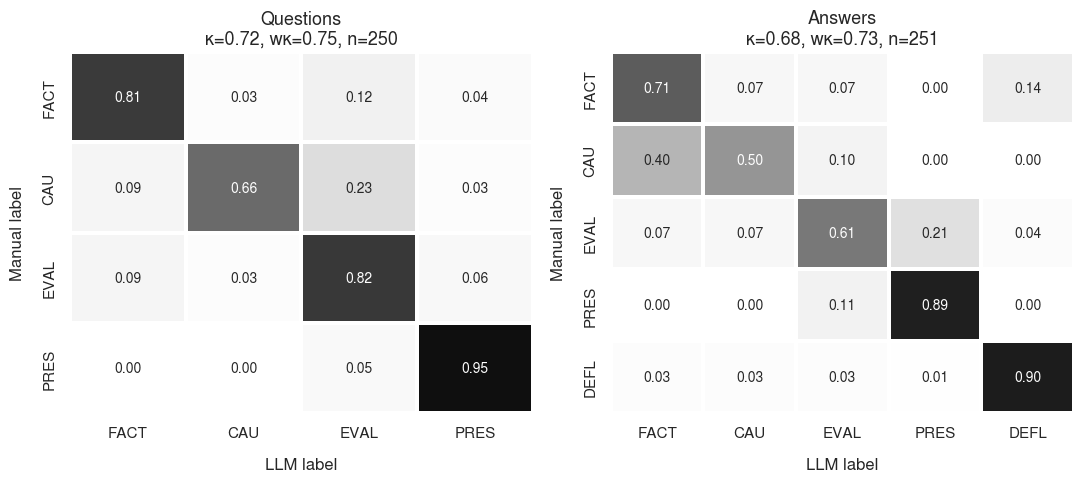

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, schema in zip(axes, ("Questions", "Answers")):
    d = iaa[schema]
    cm = confusion_matrix_df(d["y_manual"], d["y_llm"], d["labels"])
    cm_norm = cm.div(cm.sum(axis=1), axis=0).fillna(0)

    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greys", ax=ax,
                vmin=0, vmax=1, linewidths=1.5, annot_kws={"size": 10}, cbar=False)
    ax.set_title(f"{schema}\nκ={d['kappa']:.2f}, wκ={d['wkappa']:.2f}, n={d['n']}", fontsize=13)
    ax.set_xlabel("LLM label", labelpad=12)
    ax.set_ylabel("Manual label", labelpad=12)

plt.tight_layout()
plt.savefig(FIGURES / "figure3_confusion_matrices.png", dpi=200, bbox_inches="tight")
plt.show()


## 4. Table 2 — Question label distribution (N=1,778)

In [5]:
table2 = q["label"].fillna("?").value_counts().reindex(Q_LABELS + ["?"], fill_value=0).rename("N").to_frame()
table2["%"] = (table2["N"] / table2["N"].sum() * 100).round(1)
table2


,N,%
label,,
FACT,556,31.300
CAU,292,16.400
EVAL,628,35.300
PRES,294,16.500
?,8,0.400


## 5. Table 3 — Answer label distribution (N=1,703)

In [6]:
table3 = a["label"].fillna("?").value_counts().reindex(A_LABELS + ["?"], fill_value=0).rename("N").to_frame()
table3["%"] = (table3["N"] / table3["N"].sum() * 100).round(1)
table3


,N,%
label,,
FACT,493,28.900
CAU,74,4.300
EVAL,368,21.600
PRES,247,14.500
DEFL,516,30.300
?,5,0.300


## 6. Figure 1 — Q×A cross-tabulation

For each question label, the matching distribution of answer labels. Row
percentages are the primary measure of how the Court responds to each demand
type; the diagonal (matching labels) is boxed.


findfont: Font family 'Helvetica' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Helvetica' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Helvetica' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Helvetica' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Helvetica' not found.


findfont: Font family 'Arial' not found.


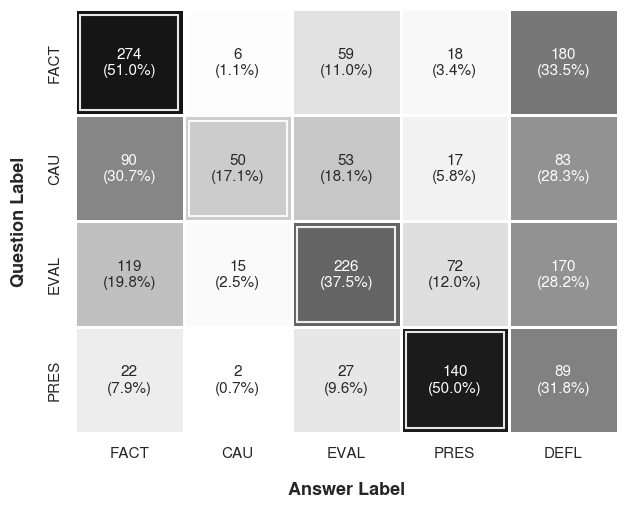

In [7]:
a_for_join = a[["src_id", "vraag_nr", "label"]].rename(columns={"label": "a_label"})
qa = q.rename(columns={"label": "q_label"}).merge(a_for_join, on=["src_id", "vraag_nr"], how="left")
qa_matched = qa[qa.q_label.notna() & qa.a_label.notna() & (qa.q_label != "?") & (qa.a_label != "?")]

ct_counts = pd.crosstab(qa_matched["q_label"], qa_matched["a_label"]).reindex(index=Q_LABELS, columns=A_LABELS, fill_value=0)
ct_norm = ct_counts.div(ct_counts.sum(axis=1), axis=0)
annot = ct_counts.astype(str) + "\n(" + (ct_norm * 100).round(1).astype(str) + "%)"

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(ct_norm, annot=annot, fmt="", cmap="Greys", annot_kws={"fontsize": 11},
            cbar=False, linecolor="white", linewidths=1, ax=ax, vmax=.55, vmin=0)

for label in Q_LABELS:
    ax.add_patch(Rectangle((A_LABELS.index(label) + .05, Q_LABELS.index(label) + .05), .9, .9,
                            fill=False, edgecolor="white", linewidth=1.5, alpha=.9))

ax.set_xlabel("Answer Label", labelpad=15, fontweight="bold", fontsize=13)
ax.set_ylabel("Question Label", labelpad=15, fontweight="bold", fontsize=13)

plt.savefig(FIGURES / "figure1_qa_crosstab.png", dpi=200, bbox_inches="tight")
plt.show()


## 7. Figure 2 — Deflection breakdown

A manually coded random sample of deflected (DEFL) answers, classified into five
deflection types: cross-reference to another answer (`CROSS_REF`), reference to
future work (`FUTURE`), politically-motivated deflection (`MIN_POL`), lack of
underlying data (`NO_DATA`), and scope-based deflection (`SCOPE`). Rows are the
question label of the deflected question.


findfont: Font family 'Helvetica' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Helvetica' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Helvetica' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Helvetica' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Helvetica' not found.


findfont: Font family 'Arial' not found.


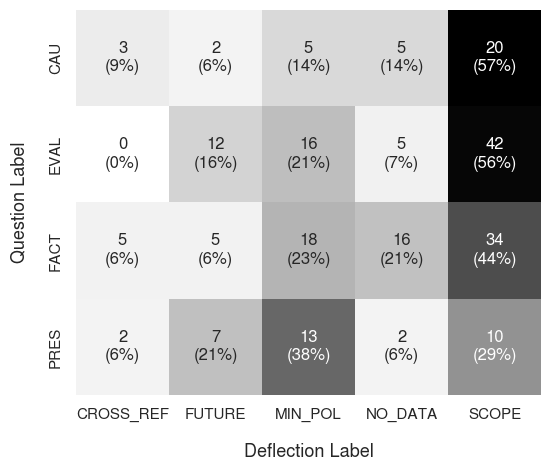

In [8]:
defl_types = defl[["src_id", "vraag_nr", "defl_types"]].dropna(subset=["defl_types"]).copy()
defl_types["defl_types"] = defl_types["defl_types"].str.split("|")
defl_types = defl_types.explode("defl_types")
defl_types["defl_types"] = defl_types["defl_types"].str.strip()

defl_joined = defl_types.merge(q[["src_id", "vraag_nr", "label"]], on=["src_id", "vraag_nr"], how="left")

dfct_counts = pd.crosstab(defl_joined["label"], defl_joined["defl_types"]).reindex(index=["CAU", "EVAL", "FACT", "PRES"])
dfct_norm = dfct_counts.div(dfct_counts.sum(axis=1), axis=0)
annot = dfct_counts.astype(str) + "\n(" + (dfct_norm * 100).round(0).astype(int).astype(str) + "%)"

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(dfct_norm, annot=annot, fmt="", cmap="Greys", cbar=False, ax=ax)
ax.set_xlabel("Deflection Label", labelpad=15, fontsize=13)
ax.set_ylabel("Question Label", labelpad=15, fontsize=13)

plt.savefig(FIGURES / "figure2_deflection_breakdown.png", dpi=200, bbox_inches="tight")
plt.show()


## 8. Table 4 — Question label distribution by policy domain

Policy domain is inferred from the parliamentary committee that submitted the
questions. Committees that were merged or split over time are grouped together
(marked with `*`).


In [9]:
COMMISSIE_MAP = {
    "Vaste commissie voor Financiën": "FIN*",
    "Vaste commissie voor Financiën en de Rijksuitgaven": "FIN*",
    "Commissie voor de Rijksuitgaven": "FIN*",
    "Vaste commissie voor Veiligheid en Justitie": "J&V",
    "Vaste commissie voor Justitie en Veiligheid": "J&V",
    "Vaste commissie voor Defensie": "DEF",
    "Vaste commissie voor Binnenlandse Zaken": "BZK*",
    "Vaste commissie voor Onderwijs, Cultuur en Wetenschap": "OCW",
    "Vaste commissie voor Infrastructuur en Milieu": "I&W*",
    "Vaste commissie voor Infrastructuur en Waterstaat": "I&W*",
    "Vaste commissie voor Economische Zaken": "EZ*",
    "Vaste commissie voor Economische Zaken en Klimaat": "EZ*",
    "Vaste commissie voor Volksgezondheid, Welzijn en Sport": "VWS",
    "Vaste commissie voor Sociale Zaken en Werkgelegenheid": "SZW",
    "Vaste commissie voor Wonen en Ruimtelijke Ordening": "WRO*",
    "Vaste commissie voor Volkshuisvesting en Ruimtelijke Ordening": "WRO*",
    "Vaste commissie voor Koninkrijksrelaties": "BZK*",
    "Vaste commissie voor Landbouw, Natuur en Voedselkwaliteit": "LNV",
    "Vaste commissie voor Klimaat en Energie": "KEN",
    "Vaste commissie voor Buitenlandse Zaken": "BuZa*",
    "Vaste commissie voor Buitenlandse Handel en Ontwikkelingssamenwerking": "BuZa*",
    "Vaste commissie voor Digitale Zaken": "BZK*",
}

domain_map = dict(zip(committees.src_id, committees.commissie.map(COMMISSIE_MAP)))
q["domain"] = q["src_id"].map(domain_map)

qd = q[q.label.notna() & (q.label != "?") & q.domain.notna()].copy()
qd["question_id"] = qd.src_id.astype(str) + "_" + qd.vraag_nr.astype(str)

ratio = pd.crosstab(qd["domain"], qd["label"], normalize="index").round(2).reindex(columns=Q_LABELS)
n_questions = qd.groupby("domain")["question_id"].nunique().rename("Questions")
n_reports = qd.groupby("domain")["src_id"].nunique().rename("Reports")
q_per_report = (n_questions / n_reports).round(0).astype(int).rename("Questions / Report")

table4 = ratio.join(n_questions).join(n_reports).join(q_per_report).sort_index()
table4


,FACT,CAU,EVAL,PRES,Questions,Reports,Questions / Report
domain,,,,,,,
BZK*,0.360,0.170,0.250,0.230,106,24,4
BuZa*,0.250,0.160,0.390,0.200,44,7,6
DEF,0.310,0.150,0.360,0.180,334,23,15
EZ*,0.370,0.210,0.420,0.000,38,8,5
FIN*,0.360,0.170,0.360,0.110,510,42,12
I&W*,0.290,0.140,0.360,0.210,69,11,6
J&V,0.330,0.170,0.290,0.210,145,10,14
KEN,0.360,0.180,0.000,0.450,11,1,11
LNV,0.200,0.060,0.630,0.110,35,4,9


## 9. Chi-square test of independence — question label × answer label

Reported in the discussion as the strength of policy domain as a predictor
(Cramér's V).


In [10]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(ct_counts)
n = ct_counts.sum().sum()
r, k = ct_counts.shape
cramers_v = np.sqrt((chi2 / n) / min(k - 1, r - 1))

print(f"Q x A label association:      chi2={chi2:.1f}, p={p:.4g}, Cramér's V={cramers_v:.3f}")

chi2_d, p_d, dof_d, _ = chi2_contingency(pd.crosstab(qd['domain'], qd['label']))
n_d = qd.shape[0]
r_d, k_d = pd.crosstab(qd['domain'], qd['label']).shape
cramers_v_d = np.sqrt((chi2_d / n_d) / min(k_d - 1, r_d - 1))

print(f"Domain x question label assoc: chi2={chi2_d:.1f}, p={p_d:.4g}, Cramér's V={cramers_v_d:.3f}")


Q x A label association:      chi2=718.7, p=4.369e-146, Cramér's V=0.374
Domain x question label assoc: chi2=83.0, p=1.409e-05, Cramér's V=0.132
